## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import f1_score, roc_auc_score, classification_report, roc_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression


## 2. Load and Clean the Dataset

In [ ]:
np.random.seed(1118)

df = pd.read_csv("../data/diabetic_data.csv")

df.replace('?', np.nan, inplace=True)


## 3. Create the prediction target

We convert the original readmission variable into a binary target:
- 1 = readmitted within 30 days
- 0 = not readmitted within 30 days

In [ ]:
target_map = {'NO': 0, '<30': 1, '>30': 0}
df['target'] = df['readmitted'].map(target_map)

## 4. Choose the predictor variables

We keep a small set of features that were supported by our EDA and likely to be useful for prediction, such as age, diagnoses, medication count, and prior hospital stay.

In [ ]:
features = [
    "age",
    "number_diagnoses",
    "time_in_hospital",
    "num_medications",
    "number_inpatient",
    "number_emergency",
    "number_outpatient",
    "discharge_disposition_id",
    "admission_type_id"
]

df = df[features + ["target"]].dropna()

df = pd.get_dummies(df, columns=["age"], drop_first=True)


## 5. Split Into Training and Testing Sets

We split the data into training and testing sets using stratification so that the class imbalance is preserved in both sets.

In [ ]:
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))


## 6. Logistic Regression Baseline Model

This is our simpler baseline model. It gives us an interpretable starting point and helps us compare whether a more flexible model improves performance.

In [23]:
logreg = LogisticRegression(max_iter=1000, class_weight="balanced")

logreg.fit(X_train, y_train)

y_pred_log = logreg.predict(X_test)
y_prob_log = logreg.predict_proba(X_test)[:, 1]

print("Logistic Regression Results:")
print("F1:", f1_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression Results:
F1: 0.25688073394495414
ROC-AUC: 0.6444401765692531
              precision    recall  f1-score   support

           0       0.92      0.70      0.79     18083
           1       0.17      0.50      0.26      2271

    accuracy                           0.68     20354
   macro avg       0.55      0.60      0.53     20354
weighted avg       0.83      0.68      0.73     20354



## 7. Random Forest Model

We used this model to see more complex relationships. We use GridSearchCV to test a few hyperparameter combinations and select the best version based on F1 score.

In [25]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42),
    param_grid,
    cv=5,
    scoring="f1"
)

grid.fit(X_train, y_train)
rf = grid.best_estimator_

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("Tuned Random Forest Results:")
print("Best params:", grid.best_params_)
print("F1:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print(classification_report(y_test, y_pred_rf))

Tuned Random Forest Results:
Best params: {'max_depth': 10, 'n_estimators': 200}
F1: 0.2730241672109732
ROC-AUC: 0.6679135347642176
              precision    recall  f1-score   support

           0       0.92      0.69      0.79     18083
           1       0.18      0.55      0.27      2271

    accuracy                           0.67     20354
   macro avg       0.55      0.62      0.53     20354
weighted avg       0.84      0.67      0.73     20354



## 8. Compare model performance

This table summarizes the main metrics and validation setup for both models so we can compare them side by side.

In [ ]:
results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Hyperparameters": "C, class_weight",
        "Validation": "5-fold CV + train/test split",
        "F1": f1_score(y_test, y_pred_log),
        "ROC-AUC": roc_auc_score(y_test, y_prob_log)
    },
    {
        "Model": "Random Forest",
        "Hyperparameters": "n_estimators, max_depth",
        "Validation": "5-fold CV + train/test split",
        "F1": f1_score(y_test, y_pred_rf),
        "ROC-AUC": roc_auc_score(y_test, y_prob_rf)
    }
])

print(results)


                 Model          Hyperparameters                    Validation  \
0  Logistic Regression          C, class_weight  5-fold CV + train/test split   
1        Random Forest  n_estimators, max_depth  5-fold CV + train/test split   

         F1   ROC-AUC  
0  0.256881  0.644440  
1  0.273024  0.667914  


## 9. ROC curve

This plot shows how well the random forest separates the two classes across different thresholds. A curve above the diagonal indicates performance better than random guessing.

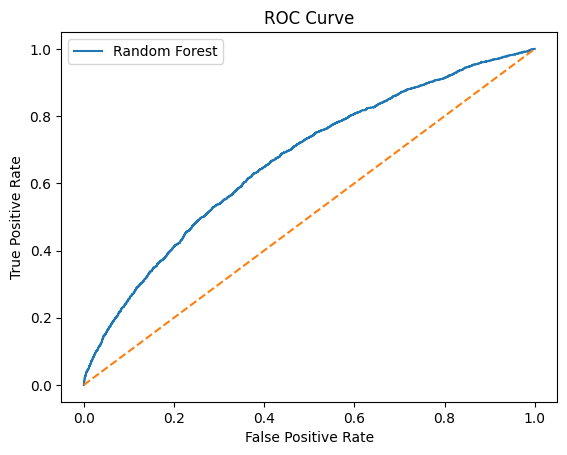

In [ ]:

fpr, tpr, _ = roc_curve(y_test, y_prob_rf)

plt.figure()
plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


## 10. Interpret the random forest model

This plot shows which variables were most important for the random forest model’s predictions.

The random forest feature importance plot suggests that prior inpatient visits, discharge disposition, and medication count are among the strongest predictors of 30-day readmission. This matches our earlier EDA, where number of diagnoses and other indicators of patient complexity appeared to separate the higher-risk group more clearly.

                     Feature  Importance
3           number_inpatient    0.333993
6   discharge_disposition_id    0.171003
2            num_medications    0.105538
1           time_in_hospital    0.084407
0           number_diagnoses    0.072734
4           number_emergency    0.065342
7          admission_type_id    0.047662
5          number_outpatient    0.042033
12               age_[50-60)    0.013486
15               age_[80-90)    0.011265


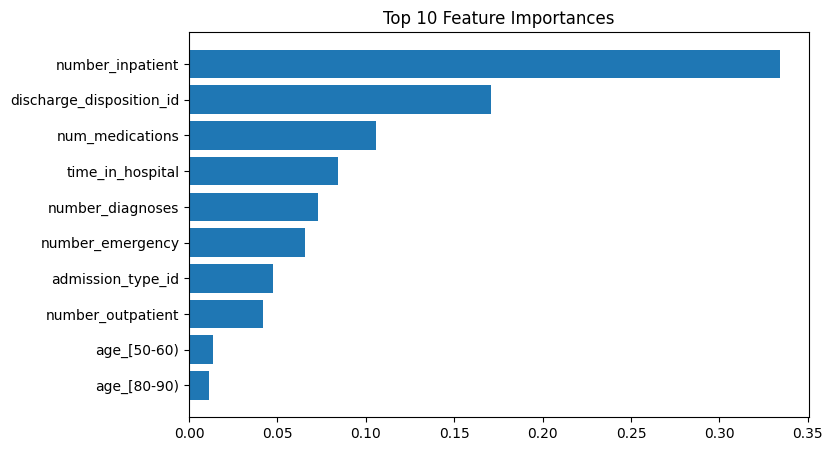

In [24]:
importances = rf.feature_importances_
feature_names = X.columns

feat_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print(feat_df.head(10))

plt.figure(figsize=(8,5))
plt.barh(feat_df.head(10)["Feature"], feat_df.head(10)["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances")
plt.show()


## 11. Final takeaway

The random forest model performed slightly better than logistic regression based on F1 score and ROC-AUC, so it was selected as the stronger model for this dataset. Because the classes are imbalanced, these metrics were more useful than accuracy. The feature importance results suggest that prior inpatient hospitalization, discharge disposition, and overall patient complexity are key predictors of 30-day readmission risk.